In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_auc_score, roc_curve, auc)
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
import time
from datetime import datetime

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

✓ All libraries imported successfully!
TensorFlow Version: 2.20.0
GPU Available: []


In [6]:
DATA_PATH = r'D:\projects\project_pashupatastra\data\application\NF-ToN-IoT-v3\data\NF-ToN-IoT-v3.csv'

print("Loading NF-ToN-IoT-v3 dataset with chunking...")
print("Using 5% sample for memory efficiency...")

chunk_size = 100_000
chunks = []
start_time = time.time()

try:
    for chunk in pd.read_csv(DATA_PATH, chunksize=chunk_size, low_memory=False):
        sample = chunk.sample(frac=0.05, random_state=42)
        chunks.append(sample)
    
    df = pd.concat(chunks, ignore_index=True)
    load_time = time.time() - start_time
    
    print(f"Dataset loaded successfully in {load_time:.2f} seconds!")
    print(f"Dataset Shape: {df.shape}")
    print(f"Total Samples: {df.shape[0]:,}")
    print(f"Total Features: {df.shape[1]}")
except FileNotFoundError:
    print("Error: Dataset file not found!")
    print(f"Please check path: {DATA_PATH}")


Loading NF-ToN-IoT-v3 dataset with chunking...
Using 5% sample for memory efficiency...
Dataset loaded successfully in 225.55 seconds!
Dataset Shape: (1376013, 55)
Total Samples: 1,376,013
Total Features: 55


In [ ]:
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nFirst 5 rows:")
print(df.head(20))
print(f"\nDataset Info:")
print(df.info())
print(f"\nColumn Names:")
print(df.columns.tolist())
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nData Types:")
print(df.dtypes)



DATASET OVERVIEW

First 5 rows:
   FLOW_START_MILLISECONDS  FLOW_END_MILLISECONDS  IPV4_SRC_ADDR  L4_SRC_PORT  \
0            1556028765785          1556028765785   192.168.1.32        62675   
1            1556028773973          1556028773973   192.168.1.30        40490   
2            1556028649557          1556028649636   192.168.1.32        43516   
3            1556028767687          1556028767687   192.168.1.32        57550   
4            1556028787511          1556028787528  192.168.1.193          445   

   IPV4_DST_ADDR  L4_DST_PORT  PROTOCOL  L7_PROTO  IN_BYTES  IN_PKTS  ...  \
0  192.168.1.195         5001         6       243        44        1  ...   
1  192.168.1.169         9011         6         0        44        1  ...   
2  192.168.1.190          110         6        23       669        6  ...   
3  192.168.1.152            9         6         0        44        1  ...   
4   192.168.1.30        33375         6        41        44        1  ...   

   SRC_TO_DST_IAT

In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"Dataset after cleaning: {df.shape}")
print(f"\nLabel Distribution:")
print(df['Label'].value_counts())

if 'Attack' in df.columns:
    print(f"\nAttack Types Distribution:")
    print(df['Attack'].value_counts())


NameError: name 'df' is not defined

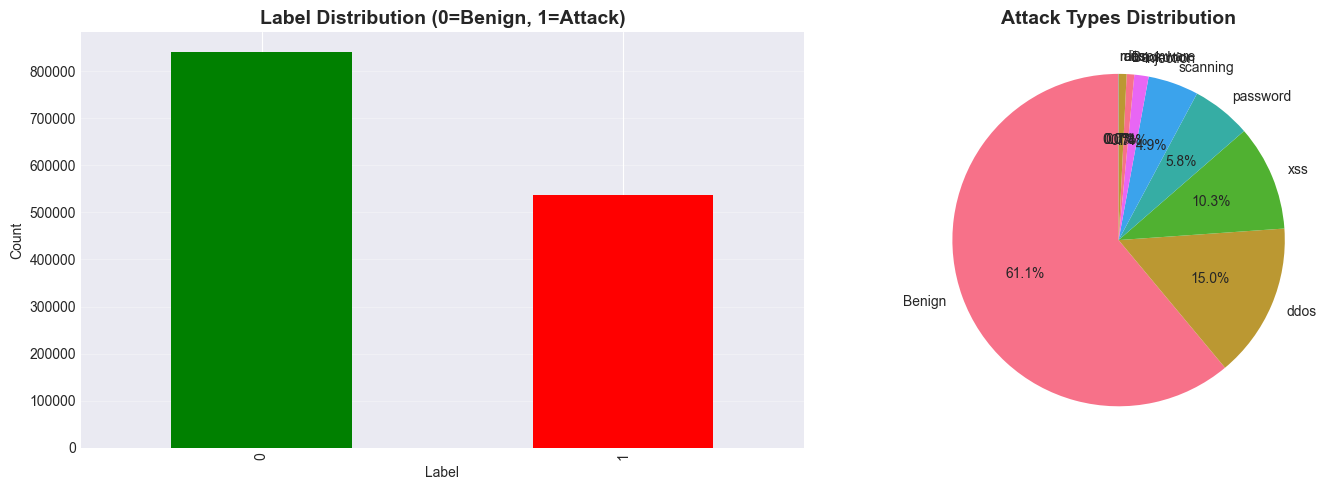

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df['Label'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Label Distribution (0=Benign, 1=Attack)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

if 'Attack' in df.columns:
    attack_counts = df['Attack'].value_counts()
    axes[1].pie(attack_counts.values, labels=attack_counts.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Attack Types Distribution', fontsize=14, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No Attack column found', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
import joblib

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

encoders = {}
for col in categorical_cols:
    if col in df.columns and col != 'Label':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

print(f"✅ Encoded {len(encoders)} categorical columns")


Categorical columns: []
✅ Encoded 0 categorical columns


In [ ]:
drop_cols = ['Label']
if 'Attack' in df.columns:
    drop_cols.append('Attack')

X = df.drop(drop_cols, axis=1)
y = df['Label']

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Features normalized")


Features shape: (1376013, 53)
Labels shape: (1376013,)
Feature columns: ['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'SRC_TO_DST_IAT_MIN

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

print(f"✅ Data reshaped for LSTM")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


Training set: (1100810, 53)
Testing set: (275203, 53)
✅ Data reshaped for LSTM
X_train shape: (1100810, 1, 53)
X_test shape: (275203, 1, 53)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        93,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,817 (573.50 KB)

 Trainable params: 146,817 (573.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training LSTM model for Application Layer Attack Detection...")
print("This may take several minutes...")

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=256,
    verbose=1
)

print("✅ Model training completed!")


Training LSTM model for Application Layer Attack Detection...
This may take several minutes...
Epoch 1/10
4301/4301 ━━━━━━━━━━━━━━━━━━━━ 92s 18ms/step - accuracy: 0.9281 - loss: 0.1967 - val_accuracy: 0.9444 - val_loss: 0.1462
Epoch 2/10
4301/4301 ━━━━━━━━━━━━━━━━━━━━ 78s 18ms/step - accuracy: 0.9468 - loss: 0.1433 - val_accuracy: 0.9542 - val_loss: 0.1303
Epoch 3/10
4301/4301 ━━━━━━━━━━━━━━━━━━━━ 77s 18ms/step - accuracy: 0.9517 - loss: 0.1314 - val_accuracy: 0.9564 - val_loss: 0.1216
Epoch 4/10
4301/4301 ━━━━━━━━━━━━━━━━━━━━ 100s 23ms/step - accuracy: 0.9536 - loss: 0.1250 - val_accuracy: 0.9591 - val_loss: 0.1205
Epoch 5/10
4301/4301 ━━━━━━━━━━━━━━━━━━━━ 99s 23ms/step - accuracy: 0.9543 - loss: 0.1219 - val_accuracy: 0.9592 - val_loss: 0.1156
Epoch 6/10
4301/4301 ━━━━━━━━━━━━━━━━━━━━ 99s 23ms/step - accuracy: 0.9559 - loss: 0.1187 - val_accuracy: 0.9597 - val_loss: 0.1138
Epoch 7/10
4301/4301 ━━━━━━━━━━━━━━━━━━━━ 96s 22ms/step - accuracy: 0.9583 - loss: 0.1152 - val_accuracy: 0.9610

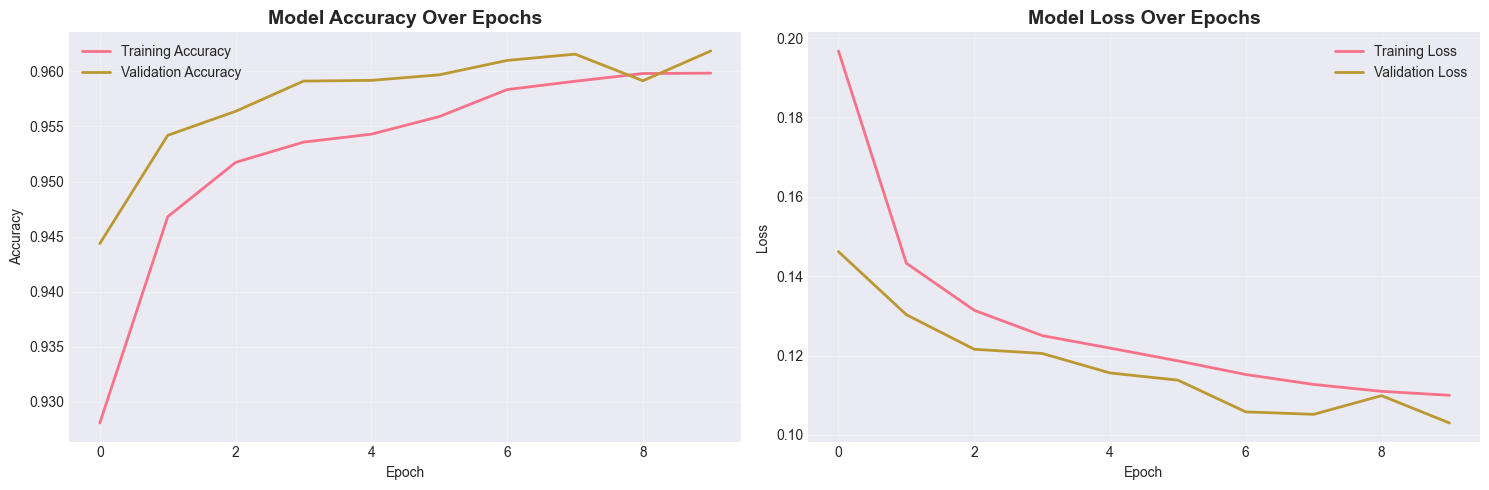

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

print("\n" + "="*60)
print("MODEL EVALUATION METRICS")
print("="*60)
print(f"\nAccuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1-Score:  {f1*100:.2f}%")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))


8601/8601 ━━━━━━━━━━━━━━━━━━━━ 60s 7ms/step

MODEL EVALUATION METRICS

Accuracy:  96.19%
Precision: 95.71%
Recall:    94.43%
F1-Score:  95.07%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign       0.96      0.97      0.97    168044
      Attack       0.96      0.94      0.95    107159

    accuracy                           0.96    275203
   macro avg       0.96      0.96      0.96    275203
weighted avg       0.96      0.96      0.96    275203



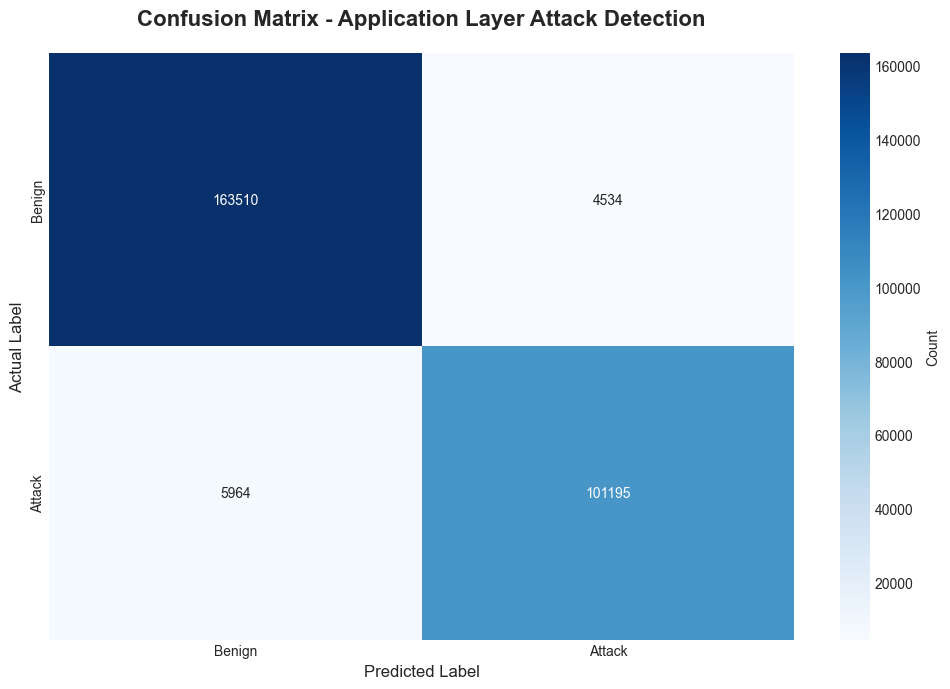


Confusion Matrix Interpretation:
True Negatives (Benign correctly identified):  163510
False Positives (Benign misclassified as Attack): 4534
False Negatives (Attack misclassified as Benign): 5964
True Positives (Attack correctly identified):  101195


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Application Layer Attack Detection', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (Benign correctly identified):  {cm[0][0]}")
print(f"False Positives (Benign misclassified as Attack): {cm[0][1]}")
print(f"False Negatives (Attack misclassified as Benign): {cm[1][0]}")
print(f"True Positives (Attack correctly identified):  {cm[1][1]}")


In [ ]:
sample_indices = np.random.choice(len(y_test), 10, replace=False)
sample_predictions = y_pred[sample_indices]
sample_actuals = y_test.iloc[sample_indices].values
sample_probs = y_pred_prob[sample_indices].flatten()

print("\n" + "="*80)
print("SAMPLE PREDICTIONS (10 random test cases)")
print("="*80)

results_df = pd.DataFrame({
    'Actual': ['Attack' if x == 1 else 'Benign' for x in sample_actuals],
    'Predicted': ['Attack' if x == 1 else 'Benign' for x in sample_predictions],
    'Confidence': [f'{p*100:.1f}%' for p in sample_probs],
    'Correct': ['✅' if sample_actuals[i] == sample_predictions[i] else '❌' 
                for i in range(len(sample_actuals))]
})

print(results_df.to_string(index=False))
print("\n" + "="*80)



SAMPLE PREDICTIONS (10 random test cases)
Actual Predicted Confidence Correct
Benign    Benign       0.3%       ✅
Benign    Benign      19.5%       ✅
Benign    Benign       0.3%       ✅
Benign    Benign       0.4%       ✅
Benign    Benign       0.0%       ✅
Benign    Benign       0.5%       ✅
Attack    Attack      98.9%       ✅
Attack    Attack      99.7%       ✅
Attack    Attack      60.1%       ✅
Attack    Attack      99.6%       ✅



In [ ]:
model_path = r'D:\projects\project_pashupatastra\models\app_layer_lstm_model.h5'
scaler_path = r'D:\projects\project_pashupatastra\models\app_layer_scaler.pkl'
columns_path = r'D:\projects\project_pashupatastra\models\app_layer_columns.pkl'

model.save(model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(X.columns.tolist(), columns_path)

for col, enc in encoders.items():
    encoder_path = rf'D:\projects\project_pashupatastra\models\app_layer_{col}_encoder.pkl'
    joblib.dump(enc, encoder_path)

print("Model saved successfully!")
print(f"   Model: {model_path}")
print(f"   Scaler: {scaler_path}")
print(f"   Columns: {columns_path}")
print(f"   Encoders: {len(encoders)} files saved")


Model saved successfully!
   Model: D:\projects\project_pashupatastra\models\app_layer_lstm_model.h5
   Scaler: D:\projects\project_pashupatastra\models\app_layer_scaler.pkl
   Columns: D:\projects\project_pashupatastra\models\app_layer_columns.pkl
   Encoders: 0 files saved


In [ ]:
print("="*80)
print("APPLICATION LAYER ATTACK DETECTION - USER INPUT PREDICTION")
print("="*80)
print("\nThis section allows you to input feature values to detect if a system")
print("is under an application layer attack.")
print("\nEnter the feature values when prompted. Press Ctrl+C to exit.")
print("="*80)

def predict_attack(user_input_dict):
    input_data = pd.DataFrame([user_input_dict])
    
    for col in categorical_cols:
        if col in input_data.columns and col in encoders:
            try:
                input_data[col] = encoders[col].transform(input_data[col].astype(str))
            except:
                print(f"Warning: Unknown value for {col}, using default encoding")
                input_data[col] = 0
    
    input_data = input_data[X.columns]
    
    input_scaled = scaler.transform(input_data)
    input_reshaped = np.reshape(input_scaled, (input_scaled.shape[0], 1, input_scaled.shape[1]))
    
    prediction_prob = model.predict(input_reshaped, verbose=0)[0][0]
    prediction = 1 if prediction_prob > 0.5 else 0
    
    return prediction, prediction_prob

print("\n📋 Required features for prediction:")
for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

print("\n" + "="*80)
print("EXAMPLE: Entering values for prediction")
print("="*80)

try:
    user_input = {}
    
    print("\nPlease enter values for each feature:")
    print("(Tip: You can use sample values from the dataset above)")
    
    for col in X.columns:
        value = input(f"\nEnter value for '{col}': ").strip()
        
        if col in df[X.columns].select_dtypes(include=[np.number]).columns:
            try:
                user_input[col] = float(value)
            except:
                print(f"Invalid numeric value, using 0")
                user_input[col] = 0
        else:
            user_input[col] = value
    
    print("\n" + "="*80)
    print("PREDICTION RESULT")
    print("="*80)
    
    prediction, probability = predict_attack(user_input)
    
    print(f"\n📊 Prediction Probability: {probability*100:.2f}%")
    
    if prediction == 1:
        print(f"\nALERT: System is under APPLICATION LAYER ATTACK!")
        print(f"    Confidence: {probability*100:.2f}%")
        print(f"\n    Recommended Actions:")
        print(f"    - Investigate suspicious network traffic")
        print(f"    - Check for SQL injection, XSS, or command injection attempts")
        print(f"    - Review application logs")
        print(f"    - Implement additional security measures")
    else:
        print(f"\nSystem appears to be BENIGN (No attack detected)")
        print(f"    Confidence: {(1-probability)*100:.2f}%")
    
    print("\n" + "="*80)
    
except KeyboardInterrupt:
    print("\n\nInput cancelled by user")
except Exception as e:
    print(f"\n\nError during prediction: {str(e)}")


APPLICATION LAYER ATTACK DETECTION - USER INPUT PREDICTION

This section allows you to input feature values to detect if a system
is under an application layer attack.

Enter the feature values when prompted. Press Ctrl+C to exit.

📋 Required features for prediction:
1. FLOW_START_MILLISECONDS
2. FLOW_END_MILLISECONDS
3. IPV4_SRC_ADDR
4. L4_SRC_PORT
5. IPV4_DST_ADDR
6. L4_DST_PORT
7. PROTOCOL
8. L7_PROTO
9. IN_BYTES
10. IN_PKTS
11. OUT_BYTES
12. OUT_PKTS
13. TCP_FLAGS
14. CLIENT_TCP_FLAGS
15. SERVER_TCP_FLAGS
16. FLOW_DURATION_MILLISECONDS
17. DURATION_IN
18. DURATION_OUT
19. MIN_TTL
20. MAX_TTL
21. LONGEST_FLOW_PKT
22. SHORTEST_FLOW_PKT
23. MIN_IP_PKT_LEN
24. MAX_IP_PKT_LEN
25. SRC_TO_DST_SECOND_BYTES
26. DST_TO_SRC_SECOND_BYTES
27. RETRANSMITTED_IN_BYTES
28. RETRANSMITTED_IN_PKTS
29. RETRANSMITTED_OUT_BYTES
30. RETRANSMITTED_OUT_PKTS
31. SRC_TO_DST_AVG_THROUGHPUT
32. DST_TO_SRC_AVG_THROUGHPUT
33. NUM_PKTS_UP_TO_128_BYTES
34. NUM_PKTS_128_TO_256_BYTES
35. NUM_PKTS_256_TO_512_BYTES
36.

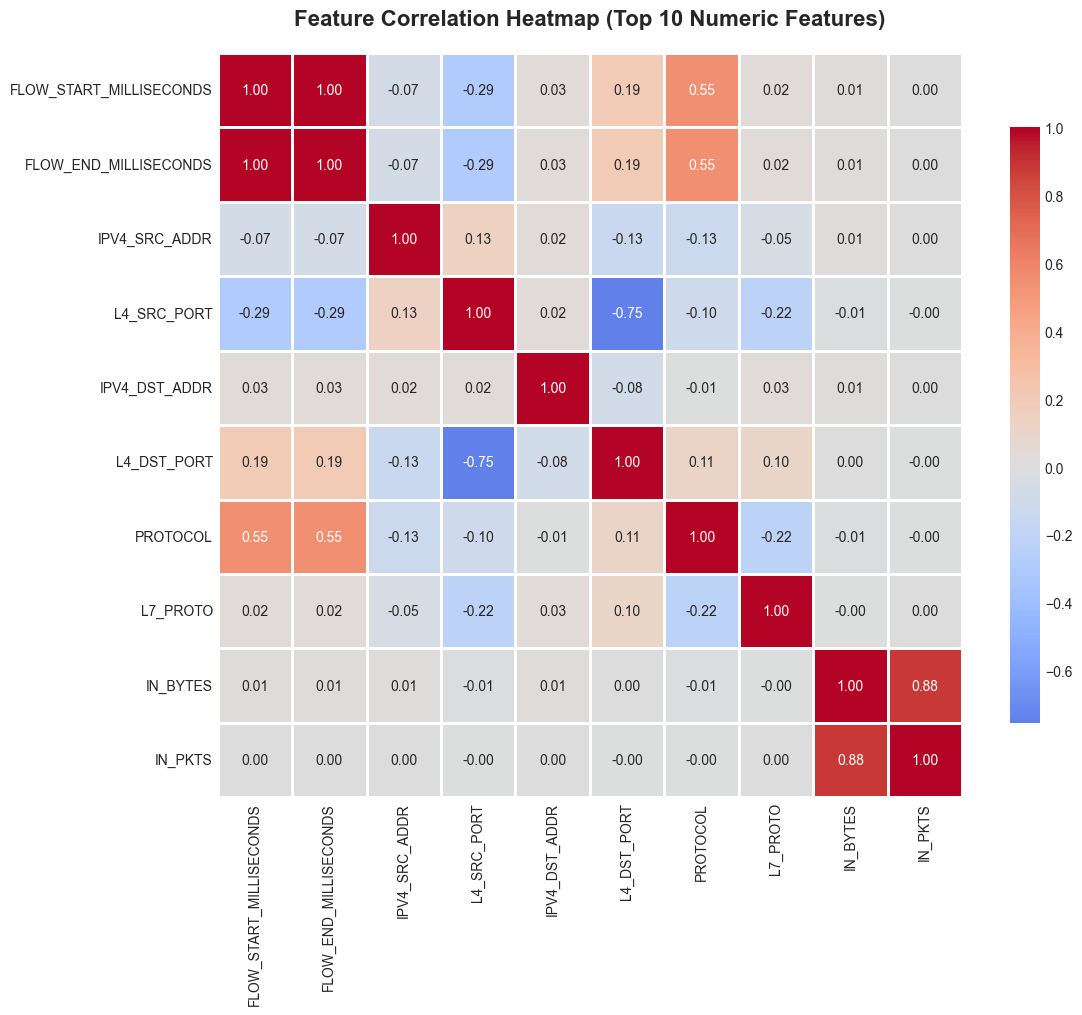


📊 Correlation Analysis:
Features with high correlation may indicate redundancy or strong relationships.


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns[:10]
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap (Top 10 Numeric Features)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 Correlation Analysis:")
print("Features with high correlation may indicate redundancy or strong relationships.")
